In [1]:
# Kütüphanelerimizi import ettik.
import torch
from torch import nn
import matplotlib.pyplot as plt
from torchvision import datasets
from torchvision.transforms import ToTensor

In [2]:
train_data = datasets.CIFAR10(
    root = "data",
    train = True,
    download = True,
    transform = ToTensor(),
    target_transform = None
)

test_data = datasets.CIFAR10(
    root = "data",
    train = False,
    download = True,
    transform = ToTensor(),
    target_transform = None
)

/usr/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [3]:
image, label = train_data[0]
# tuple unpacking yapınca ilki görselin tensor'u ikincisi ise label.

In [4]:
image
# Bu bize tensor'u verecek.
# Bütün rakamların 0 ile 1 arasında olmasının sebebi normalize edilmesi.

tensor([[[0.2314, 0.1686, 0.1961,  ..., 0.6196, 0.5961, 0.5804],
         [0.0627, 0.0000, 0.0706,  ..., 0.4824, 0.4667, 0.4784],
         [0.0980, 0.0627, 0.1922,  ..., 0.4627, 0.4706, 0.4275],
         ...,
         [0.8157, 0.7882, 0.7765,  ..., 0.6275, 0.2196, 0.2078],
         [0.7059, 0.6784, 0.7294,  ..., 0.7216, 0.3804, 0.3255],
         [0.6941, 0.6588, 0.7020,  ..., 0.8471, 0.5922, 0.4824]],

        [[0.2431, 0.1804, 0.1882,  ..., 0.5176, 0.4902, 0.4863],
         [0.0784, 0.0000, 0.0314,  ..., 0.3451, 0.3255, 0.3412],
         [0.0941, 0.0275, 0.1059,  ..., 0.3294, 0.3294, 0.2863],
         ...,
         [0.6667, 0.6000, 0.6314,  ..., 0.5216, 0.1216, 0.1333],
         [0.5451, 0.4824, 0.5647,  ..., 0.5804, 0.2431, 0.2078],
         [0.5647, 0.5059, 0.5569,  ..., 0.7216, 0.4627, 0.3608]],

        [[0.2471, 0.1765, 0.1686,  ..., 0.4235, 0.4000, 0.4039],
         [0.0784, 0.0000, 0.0000,  ..., 0.2157, 0.1961, 0.2235],
         [0.0824, 0.0000, 0.0314,  ..., 0.1961, 0.1961, 0.

In [5]:
label
# Bu da bize hangi label'da oldugunu veriyor.

6

In [6]:
image.shape
# Size -> 3x32x32 çıktı yani RGB ve 32 ye 32 pixel olarak veriyor.

torch.Size([3, 32, 32])

In [7]:
train_data.classes[label]

'frog'

In [8]:
train_data

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [9]:
len(train_data), len(test_data)

(50000, 10000)

In [10]:
class_names = train_data.classes
class_names
# bize mevcut sınıfları verir.

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

Text(0.5, 1.0, 'bird')

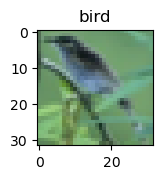

In [11]:
image , label = train_data[800]
image = image.permute(1,2,0) # permute ediyoruz çünkü matplotlib öyle kabul ediyor (32x32x3 şeklinde)
plt.figure(figsize=(1.5,1.5))
plt.imshow(image) # Görseli imshow ile görebiliyoruz.
plt.title(class_names[label])

In [12]:
from torchvision import transforms

In [13]:
# Hız açısından avantaj sağlar. 
transform = transforms.Compose([ # İşlemleri sırasıyla uygular.
    transforms.ToTensor(), # Matrise çevirir [0,255] den [0.0,1.0] arasında getirir. (Kanal,Boy,En) formatında yazar.
    transforms.Normalize( # Veriyi standartlaştırır.
        mean=[0.491, 0.482, 0.446],
        std =[0.247, 0.243, 0.261])
])

In [14]:
train_data = datasets.CIFAR10(
    root = "data",
    train = True,
    download = True,
    transform = transform,
    target_transform = None
)

test_data = datasets.CIFAR10(
    root = "data",
    train = False,
    download = True,
    transform = transform,
)

In [15]:
image , label = train_data[0]

In [16]:
image

tensor([[[-1.0511e+00, -1.3052e+00, -1.1940e+00,  ...,  5.2068e-01,
           4.2542e-01,  3.6191e-01],
         [-1.7338e+00, -1.9879e+00, -1.7021e+00,  ..., -3.5008e-02,
          -9.8516e-02, -5.0885e-02],
         [-1.5909e+00, -1.7338e+00, -1.2099e+00,  ..., -1.1439e-01,
          -8.2639e-02, -2.5728e-01],
         ...,
         [ 1.3145e+00,  1.2034e+00,  1.1558e+00,  ...,  5.5243e-01,
          -1.0988e+00, -1.1464e+00],
         [ 8.6997e-01,  7.5883e-01,  9.6523e-01,  ...,  9.3348e-01,
          -4.4780e-01, -6.7008e-01],
         [ 8.2234e-01,  6.7945e-01,  8.5409e-01,  ...,  1.4415e+00,
           4.0954e-01, -3.5008e-02]],

        [[-9.8297e-01, -1.2412e+00, -1.2089e+00,  ...,  1.4670e-01,
           3.3729e-02,  1.7591e-02],
         [-1.6608e+00, -1.9835e+00, -1.8544e+00,  ..., -5.6338e-01,
          -6.4407e-01, -5.7952e-01],
         [-1.5962e+00, -1.8706e+00, -1.5478e+00,  ..., -6.2794e-01,
          -6.2794e-01, -8.0545e-01],
         ...,
         [ 7.5995e-01,  4

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9084703..2.10758].


Text(0.5, 1.0, 'truck')

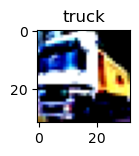

In [17]:
image , label = train_data[1]
image = image.permute(1,2,0)
plt.figure(figsize=(1.2,1.2))
plt.imshow(image)
plt.title(class_names[label])

In [18]:
# Dataloader'ı import ediyoruz.
from torch.utils.data import DataLoader

In [19]:
# Sabit bir batch size belirledik.
BATCH_SIZE = 32
# Train ve test için batch size belirledik ve shuffle ettik.
train_dataloader = DataLoader(dataset=train_data, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader  = DataLoader(dataset=test_data, batch_size=BATCH_SIZE, shuffle=False) # Testde shuffle etmeye gerek yok.

In [20]:
len(train_dataloader), len(test_dataloader)

(1563, 313)

In [21]:
train_dataloader.dataset

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=[0.491, 0.482, 0.446], std=[0.247, 0.243, 0.261])
           )

In [22]:
# Datasetimizde bir değişiklik yok.
train_dataloader.dataset[0][0].shape

torch.Size([3, 32, 32])

In [23]:
# Datamızı düzleştiriyoruz.
flatten_model = nn.Flatten()

first_data = train_dataloader.dataset[0][0]
flatten_data = flatten_model(first_data)

print(first_data.shape)
print(flatten_data.shape)

torch.Size([3, 32, 32])
torch.Size([3, 1024])


In [24]:
linear_model = nn.Linear(in_features=10,out_features=10)

In [37]:
class CIFAR10Classifier(nn.Module):

    def __init__(self, input_shape:int , output_shape:int , hidden_unit:int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_shape,hidden_unit),
            nn.Linear(hidden_unit,output_shape)
        )
    def forward(self,x):
        return self.layer_stack(x)

In [38]:
torch.manual_seed(42)
model = CIFAR10Classifier(
    input_shape=3072,
    hidden_unit = 32,
    output_shape=len(class_names)
)

In [39]:
model_0 = torch.compile(model)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(),lr=0.01)

In [40]:
def calculate_accuracy(y_true,y_pred):
    correct = torch.eq(y_true,y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

Batch Number : 0
Batch Number : 500
Batch Number : 1000
Batch Number : 1500
Train Loss:2.4824705123901367, Test Loss:2.5139360427856445, Test Accuracy:27.216453674121407
Batch Number : 0
Batch Number : 500
Batch Number : 1000
Batch Number : 1500
Train Loss:2.526881456375122, Test Loss:2.427752733230591, Test Accuracy:27.126597444089455
Batch Number : 0
Batch Number : 500
Batch Number : 1000
Batch Number : 1500
Train Loss:2.5109453201293945, Test Loss:2.6527469158172607, Test Accuracy:28.374600638977636
Batch Number : 0
Batch Number : 500
Batch Number : 1000
Batch Number : 1500
Train Loss:2.5178885459899902, Test Loss:2.5821237564086914, Test Accuracy:26.058306709265175
Batch Number : 0
Batch Number : 500
Batch Number : 1000
Batch Number : 1500
Train Loss:2.5313570499420166, Test Loss:2.3313090801239014, Test Accuracy:28.87380191693291
Batch Number : 0
Batch Number : 500
Batch Number : 1000
Batch Number : 1500
Train Loss:2.526078701019287, Test Loss:2.7366750240325928, Test Accuracy:25.

In [44]:
def evaluate_model_performance(model : torch.nn.Module,
                               data_loader : torch.utils.data.DataLoader,
                               loss_fn : torch.nn.Module,
                               accuracy_fn):
    loss = 0
    acc = 0

    model.eval()
    with torch.inference_mode():
        for X,y in data_loader:
            y_pred = model(X)
            loss += loss_fn(y_pred,y)
            acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))
        loss /= len(data_loader)
        acc /= len(data_loader)
        
    return {"model_name" : model.__class__.__name__,
           "model_loss" : loss.item(),
           "model_accuracy" : acc}

In [45]:
model_0_results = evaluate_model_performance(model=model_0,
                                             data_loader=test_dataloader,
                                             loss_fn=loss_fn,
                                             accuracy_fn=calculate_accuracy)

In [46]:
model_0_results

{'model_name': 'OptimizedModule',
 'model_loss': 2.3944618701934814,
 'model_accuracy': 26.797124600638977}

In [49]:
class CIFAR10ClassifierNonLinear(nn.Module):

    def __init__(self, input_shape:int , output_shape:int , hidden_unit:int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_shape,hidden_unit),
            nn.ReLU(),
            nn.Linear(hidden_unit,output_shape)
        )
    def forward(self,x):
        return self.layer_stack(x)

In [52]:
torch.manual_seed(42)
model_1 = CIFAR10ClassifierNonLinear(
    input_shape=3072,
    hidden_unit = 32,
    output_shape=len(class_names)
)

In [53]:
model_1 = torch.compile(model_1)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_1.parameters(),lr=0.01)

In [54]:
torch.manual_seed(42)
epochs = 10

for epoch in range(epochs):
    train_loss = 0

    for batch, (X,y) in enumerate(train_dataloader):
        model_1.train()
        y_pred = model_1(X)
        loss = loss_fn(y_pred,y)
        train_loss += loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        if batch % 500 == 0:
            print(f"Batch Number : {batch}")
    train_loss /= len(train_dataloader) 

    test_loss = 0
    test_acc = 0
    model_1.eval()
    with torch.inference_mode():
        for X,y in test_dataloader:
            test_pred = model_1(X)
            test_loss += loss_fn(test_pred , y)
            test_acc += calculate_accuracy(y_true=y, y_pred = test_pred.argmax(dim=1))
        test_loss /= len(test_dataloader)
        test_acc /= len(test_dataloader)
    print(f"Train Loss:{train_loss}, Test Loss:{test_loss}, Test Accuracy:{test_acc}")

Batch Number : 0
Batch Number : 500
Batch Number : 1000
Batch Number : 1500
Train Loss:2.3467588424682617, Test Loss:2.354398727416992, Test Accuracy:27.81549520766773
Batch Number : 0
Batch Number : 500
Batch Number : 1000
Batch Number : 1500
Train Loss:2.2935357093811035, Test Loss:2.5483150482177734, Test Accuracy:28.334664536741215
Batch Number : 0
Batch Number : 500
Batch Number : 1000
Batch Number : 1500
Train Loss:2.2386388778686523, Test Loss:2.396958112716675, Test Accuracy:29.422923322683705
Batch Number : 0
Batch Number : 500
Batch Number : 1000
Batch Number : 1500
Train Loss:2.197352647781372, Test Loss:2.4263505935668945, Test Accuracy:28.614217252396166
Batch Number : 0
Batch Number : 500
Batch Number : 1000
Batch Number : 1500
Train Loss:2.1884078979492188, Test Loss:2.132662773132324, Test Accuracy:29.333067092651756
Batch Number : 0
Batch Number : 500
Batch Number : 1000
Batch Number : 1500
Train Loss:2.1527421474456787, Test Loss:2.0782554149627686, Test Accuracy:30.3

In [55]:
model_1_results = evaluate_model_performance(model=model_1,
                                             data_loader=test_dataloader,
                                             loss_fn=loss_fn,
                                             accuracy_fn=calculate_accuracy)

In [56]:
model_1_results

{'model_name': 'OptimizedModule',
 'model_loss': 2.161986827850342,
 'model_accuracy': 26.647364217252395}

In [57]:
model_0_results

{'model_name': 'OptimizedModule',
 'model_loss': 2.3944618701934814,
 'model_accuracy': 26.797124600638977}

In [112]:
class CIFAR10ClassifierCNN(nn.Module):
    def __init__(self, input_shape:int, hidden_units: int, output_shape:int):
        super().__init__()
        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels = input_shape,
                      out_channels = hidden_units,
                      kernel_size = 3, 
                      stride = 1,
                      padding = 1),
            nn.GELU(),
            nn.Conv2d(in_channels = hidden_units,
                      out_channels = hidden_units,
                      kernel_size = 3, 
                      stride = 1,
                      padding = 1),
            nn.GELU(),
            nn.MaxPool2d(kernel_size = 2,
                         stride = 2)
        )
        self.block_2 = nn.Sequential(
            nn.Conv2d(in_channels = hidden_units,
                      out_channels = hidden_units,
                      kernel_size = 3, 
                      padding = 1),
            nn.GELU(),
            nn.Conv2d(in_channels = hidden_units,
                      out_channels = hidden_units,
                      kernel_size = 3, 
                      padding = 1),
            nn.GELU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units * 8 * 8, 
                      out_features=output_shape)
        )

    def forward(self,x):
        return self.classifier(self.block_2(self.block_1(x)))

In [113]:
#torch.manual_seed(42)

model_2 = CIFAR10ClassifierCNN(input_shape = 3,
                               hidden_units = 32,
                               output_shape = len(class_names),
                              )

In [114]:
model_2

CIFAR10ClassifierCNN(
  (block_1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): GELU(approximate='none')
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): GELU(approximate='none')
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): GELU(approximate='none')
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): GELU(approximate='none')
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=10, bias=True)
  )
)

In [116]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_2.parameters(), lr = 0.001)

In [117]:
torch.manual_seed(42)
epochs = 10

for epoch in range(epochs):
    train_loss = 0

    for batch, (X,y) in enumerate(train_dataloader):
        model_2.train()
        y_pred = model_2(X)
        loss = loss_fn(y_pred,y)
        train_loss += loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        if batch % 500 == 0:
            print(f"Batch Number : {batch}")
    train_loss /= len(train_dataloader) 

    test_loss = 0
    test_acc = 0
    model_2.eval()
    with torch.inference_mode():
        for X,y in test_dataloader:
            test_pred = model_2(X)
            test_loss += loss_fn(test_pred , y)
            test_acc += calculate_accuracy(y_true=y, y_pred = test_pred.argmax(dim=1))
        test_loss /= len(test_dataloader)
        test_acc /= len(test_dataloader)
    print(f"Train Loss:{train_loss:.5f}, Test Loss:{test_loss:.5f}, Test Accuracy:{test_acc:.2f}%\n")

Batch Number : 0
Batch Number : 500
Batch Number : 1000
Batch Number : 1500
Train Loss:1.23161, Test Loss:0.92968, Test Accuracy:67.45%

Batch Number : 0
Batch Number : 500
Batch Number : 1000
Batch Number : 1500
Train Loss:0.81129, Test Loss:0.79002, Test Accuracy:72.65%

Batch Number : 0
Batch Number : 500
Batch Number : 1000
Batch Number : 1500
Train Loss:0.67958, Test Loss:0.75175, Test Accuracy:74.53%

Batch Number : 0
Batch Number : 500
Batch Number : 1000
Batch Number : 1500
Train Loss:0.60108, Test Loss:0.74726, Test Accuracy:74.86%

Batch Number : 0
Batch Number : 500
Batch Number : 1000
Batch Number : 1500
Train Loss:0.54147, Test Loss:0.74911, Test Accuracy:74.28%

Batch Number : 0
Batch Number : 500
Batch Number : 1000
Batch Number : 1500
Train Loss:0.49435, Test Loss:0.74868, Test Accuracy:74.73%

Batch Number : 0
Batch Number : 500
Batch Number : 1000
Batch Number : 1500
Train Loss:0.45626, Test Loss:0.77702, Test Accuracy:74.67%

Batch Number : 0
Batch Number : 500
Batch

In [120]:
model_2_results = evaluate_model_performance(model=model_2,
                                             data_loader=test_dataloader,
                                             loss_fn=loss_fn,
                                             accuracy_fn=calculate_accuracy)

In [121]:
model_0_results

{'model_name': 'OptimizedModule',
 'model_loss': 2.3944618701934814,
 'model_accuracy': 26.797124600638977}

In [122]:
model_1_results

{'model_name': 'OptimizedModule',
 'model_loss': 2.161986827850342,
 'model_accuracy': 26.647364217252395}

In [123]:
model_2_results

{'model_name': 'CIFAR10ClassifierCNN',
 'model_loss': 0.8257656693458557,
 'model_accuracy': 76.05830670926518}

In [124]:
def make_predictions(model: torch.nn.Module, data: list):
    """
    data: [img_tensor, img_tensor, ...]  # her biri [C, H, W]
    return: [N, num_classes] olasılık tensörü
    """
    pred_probs = []
    model.eval()

    with torch.inference_mode():
        for sample in data:
            # [C, H, W] -> [1, C, H, W]
            sample = sample.unsqueeze(0)

            # Logits al
            pred_logit = model(sample)    # shape: [1, num_classes]

            # Softmax ile olasılığa çevir
            prob = torch.softmax(pred_logit, dim=1)  # [1, num_classes]

            # Batch boyutunu sıkıştır
            pred_probs.append(prob.squeeze(0))       # [num_classes]

    # Hepsini birleştir → [N, num_classes]
    return torch.stack(pred_probs)

In [125]:
import random
def show_random_predictions(model, dataset, class_names, n=9):
    model.eval()
    
    plt.figure(figsize=(4, 4))

    # random 9 index seç
    indices = random.sample(range(len(dataset)), n)

    with torch.inference_mode():
        for i, idx in enumerate(indices):
            img, true_label = dataset[idx]

            # modele uygun hale getir
            img_input = img.unsqueeze(0)  
            logits = model(img_input)
            pred_label = logits.argmax(dim=1).item()

            # görseli çizmek için permute
            img_show = img.permute(1, 2, 0)

            # doğru mu yanlış mı?
            correct = (pred_label == true_label)
            color = "green" if correct else "red"

            # subplot
            plt.subplot(3, 3, i + 1)
            plt.imshow(img_show)
            plt.axis("off")

            plt.title(
                f"Pred: {class_names[pred_label]}\nTrue: {class_names[true_label]}",
                color=color,
                fontsize=10
            )

    plt.tight_layout()
    plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.781456..2.1316872].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3369057..2.002404].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9878542..1.3621498].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7898813..2.092555].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8767167..2.1226053].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5115504..1.3563218].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9512628..

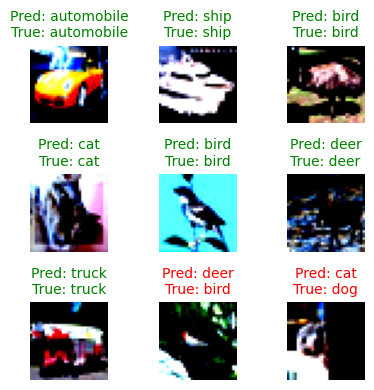

In [130]:
show_random_predictions(model_2, test_data, class_names)